## Task 1
import pandas as pd
import matplotlib


In [8]:
import pandas as pd
games = pd.read_csv("C:\DDI\Case_Studies\pandas-chess-student\data\chess_games.csv")

In [9]:
games.describe()

,created_at,last_move_at,turns,white_rating,black_rating,opening_ply
count,2.005800e+04,2.005800e+04,20058.000000,20058.000000,20058.000000,20058.000000
mean,1.483617e+12,1.483618e+12,60.465999,1596.631868,1588.831987,4.816981
std,2.850151e+10,2.850140e+10,33.570585,291.253376,291.036126,2.797152
min,1.376772e+12,1.376772e+12,1.000000,784.000000,789.000000,1.000000
25%,1.477548e+12,1.477548e+12,37.000000,1398.000000,1391.000000,3.000000
50%,1.496010e+12,1.496010e+12,55.000000,1567.000000,1562.000000,4.000000
75%,1.503170e+12,1.503170e+12,79.000000,1793.000000,1784.000000,6.000000
max,1.504493e+12,1.504494e+12,349.000000,2700.000000,2723.000000,28.000000


In [10]:
games.dtypes

id                 object
rated                bool
created_at        float64
last_move_at      float64
turns               int64
victory_status     object
winner             object
increment_code     object
white_id           object
white_rating        int64
black_id           object
black_rating        int64
moves              object
opening_eco        object
opening_name       object
opening_ply         int64
dtype: object

In [11]:
#1. black and white rating and turns is numerical. Opening name and winners are categorical.

## Task 2

<Axes: xlabel='winner'>

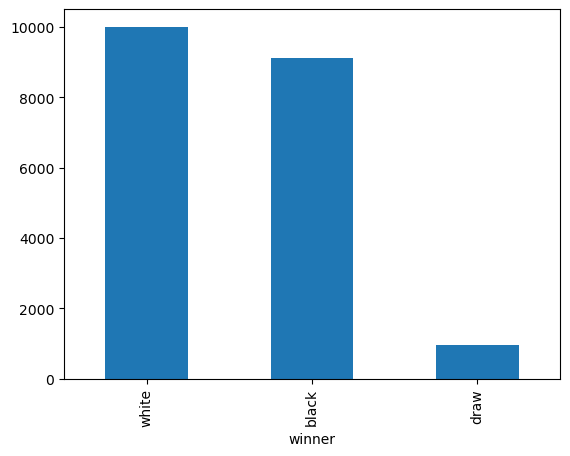

In [12]:
games['winner'].value_counts().plot(kind = 'bar')

## Task 3

<Axes: ylabel='Frequency'>

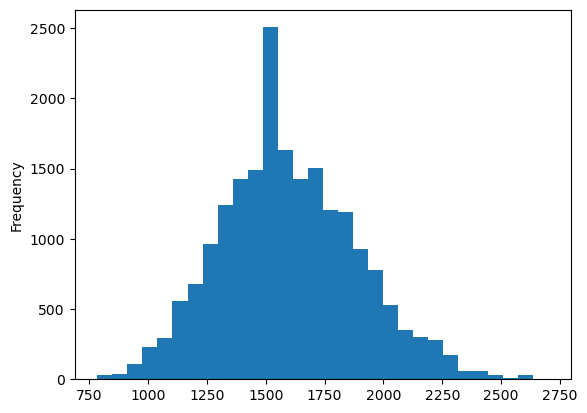

In [13]:
games["white_rating"].plot(kind = "hist", bins = 30)

<Axes: ylabel='Frequency'>

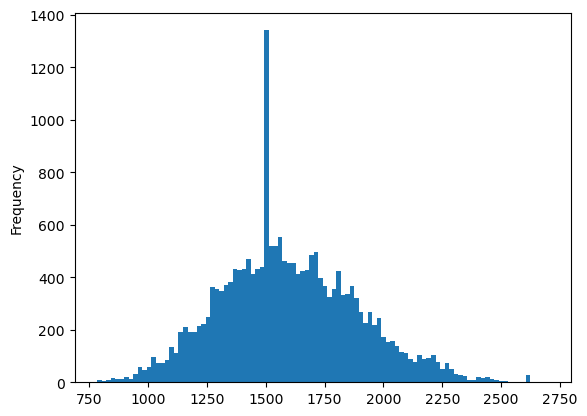

In [14]:
games["white_rating"].plot(kind = "hist", bins = 100)

<Axes: ylabel='Frequency'>

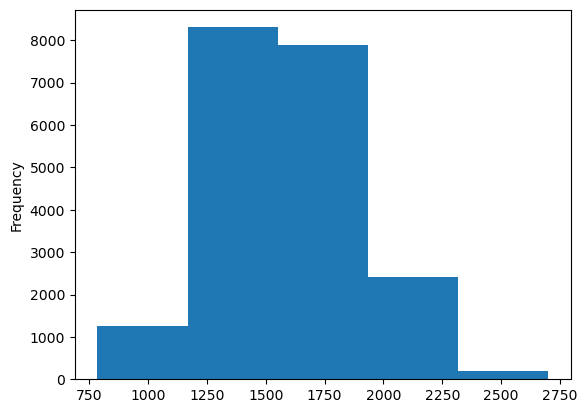

In [15]:
games["white_rating"].plot(kind = "hist", bins = 5)

In [ ]:
# The 100 bins makes it more harder to generalize but shows more points. The 5 bins showed a more generalization of the data without getting into weeds.

## Task4


<Axes: xlabel='white_rating', ylabel='black_rating'>

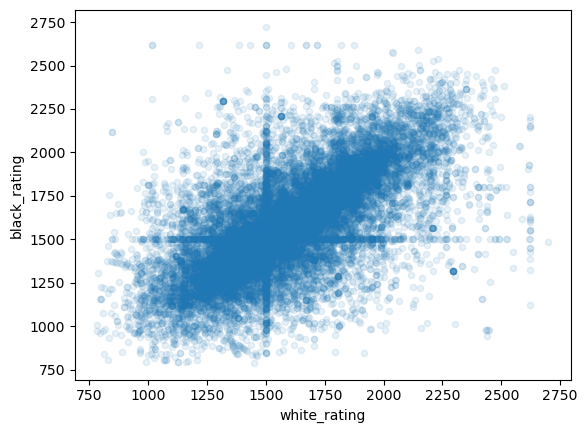

In [17]:
games.plot(kind="scatter", x="white_rating", y= "black_rating", alpha = 0.1)

#### The pattern slopes up which means the correlation is positive.

## Task 5

In [18]:
#The chart shows that there is a positive correlation between black_rating and white_rating.
#Players on both ends of spectrum won't play each other so that there is not an advantage.

## Task 6

In [19]:
games.describe()

,created_at,last_move_at,turns,white_rating,black_rating,opening_ply
count,2.005800e+04,2.005800e+04,20058.000000,20058.000000,20058.000000,20058.000000
mean,1.483617e+12,1.483618e+12,60.465999,1596.631868,1588.831987,4.816981
std,2.850151e+10,2.850140e+10,33.570585,291.253376,291.036126,2.797152
min,1.376772e+12,1.376772e+12,1.000000,784.000000,789.000000,1.000000
25%,1.477548e+12,1.477548e+12,37.000000,1398.000000,1391.000000,3.000000
50%,1.496010e+12,1.496010e+12,55.000000,1567.000000,1562.000000,4.000000
75%,1.503170e+12,1.503170e+12,79.000000,1793.000000,1784.000000,6.000000
max,1.504493e+12,1.504494e+12,349.000000,2700.000000,2723.000000,28.000000


In [20]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usage: 2.3+ MB


<Axes: ylabel='Frequency'>

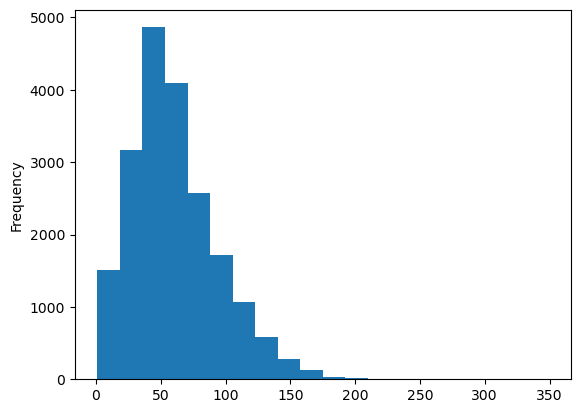

In [27]:
games['turns'].plot(kind = "hist", bins = 20)

In [25]:
games['turns']

0         13
1         16
2         61
3         61
4         95
        ... 
20053     24
20054     82
20055     35
20056    109
20057     78
Name: turns, Length: 20058, dtype: int64

In [ ]:
#It is discrete but using a bar chart would take up to much memory and hard to read so we did as continous using histogram.


## Task 7

avg_turns = games.groupby("victory_status")["turns"].mean()

In [30]:
avg_turns = games.groupby("victory_status")["turns"].mean().sort_values(ascending=False)
print(avg_turns)

victory_status
draw         83.781457
outoftime    72.742857
mate         65.415020
resign       53.912533
Name: turns, dtype: float64


In [ ]:
#The draw takes the longest on average. It is not a surprise since it runs the full length of time or close to it.


## Task 8

In [34]:
games["start_date"] = pd.to_datetime(games["created_at"], unit="ms")

<Axes: xlabel='start_date'>

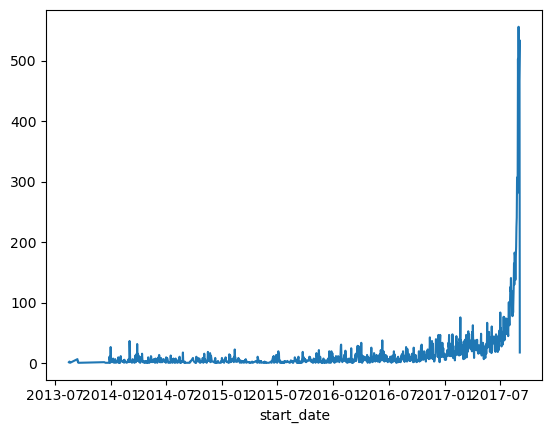

In [36]:
daily = games["start_date"].dt.date.value_counts().sort_index()
daily.plot(kind = "line")


In [ ]:
#There would be too many columns
